<a href="https://colab.research.google.com/github/sudenazerdem/nasdaq-kpi-analysis/blob/main/KPI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install yfinance

In [3]:
import yfinance as yf
import pandas as pd

In [4]:
companies = {
    "NVDA": ("2024-01-01", "2025-01-01"),  # 12 ay
    "MSFT": ("2024-04-01", "2025-01-01"),  # 9 ay
    "PLTR": ("2024-07-01", "2025-01-01"),  # 6 ay
    "TSLA": ("2024-10-01", "2025-01-01"),  # 3 ay
    "META": ("2024-12-01", "2025-01-01"),  # 1 ay
}
all_data = {}

for ticker, (start, end) in companies.items():
    stock = yf.Ticker(ticker)
    df = stock.history(start=start, end=end, interval="1d")
    all_data[ticker] = df
    print(f"{ticker}: {len(df)} rows downloaded")

NVDA: 252 rows downloaded
MSFT: 191 rows downloaded
PLTR: 128 rows downloaded
TSLA: 64 rows downloaded
META: 21 rows downloaded


In [5]:
for ticker, df in all_data.items():
    print(f"\n=== {ticker} ===")
    print(df["Close"].head())



=== NVDA ===
Date
2024-01-02 00:00:00-05:00    48.138573
2024-01-03 00:00:00-05:00    47.539944
2024-01-04 00:00:00-05:00    47.968681
2024-01-05 00:00:00-05:00    49.067005
2024-01-08 00:00:00-05:00    52.221077
Name: Close, dtype: float64

=== MSFT ===
Date
2024-04-01 00:00:00-04:00    418.151886
2024-04-02 00:00:00-04:00    415.069183
2024-04-03 00:00:00-04:00    414.094208
2024-04-04 00:00:00-04:00    411.563049
2024-04-05 00:00:00-04:00    419.087555
Name: Close, dtype: float64

=== PLTR ===
Date
2024-07-01 00:00:00-04:00    25.879999
2024-07-02 00:00:00-04:00    25.830000
2024-07-03 00:00:00-04:00    25.850000
2024-07-05 00:00:00-04:00    27.230000
2024-07-08 00:00:00-04:00    27.700001
Name: Close, dtype: float64

=== TSLA ===
Date
2024-10-01 00:00:00-04:00    258.019989
2024-10-02 00:00:00-04:00    249.020004
2024-10-03 00:00:00-04:00    240.660004
2024-10-04 00:00:00-04:00    250.080002
2024-10-07 00:00:00-04:00    240.830002
Name: Close, dtype: float64

=== META ===
Date
202

In [12]:
from datetime import datetime
import matplotlib.pyplot as plt

all_clean = {}
for ticker, df in all_data.items():
    df_clean = df[["Close"]].reset_index()
    df_clean.columns = ["Date", "Close"]
    df_clean["Date"] = pd.to_datetime(df_clean["Date"]).dt.tz_localize(None)
    df_clean["Ticker"] = ticker
    df_clean.to_csv(f"{ticker}_close.csv", index=False)
    all_clean[ticker] = df_clean
    print(f"{ticker} saved! — {len(df_clean)} rows")

print("\nDone!")
print(all_clean["NVDA"].head())

NVDA saved! — 252 rows
MSFT saved! — 191 rows
PLTR saved! — 128 rows
TSLA saved! — 64 rows
META saved! — 21 rows

Done!
        Date      Close Ticker
0 2024-01-02  48.138573   NVDA
1 2024-01-03  47.539944   NVDA
2 2024-01-04  47.968681   NVDA
3 2024-01-05  49.067005   NVDA
4 2024-01-08  52.221077   NVDA


In [13]:
for ticker in companies.keys():
    df_multiple = pd.read_csv(f"{ticker}_close.csv")
    print(f"\n=== {ticker} ===")
    print(df_multiple.head())


=== NVDA ===
         Date      Close Ticker
0  2024-01-02  48.138573   NVDA
1  2024-01-03  47.539944   NVDA
2  2024-01-04  47.968681   NVDA
3  2024-01-05  49.067005   NVDA
4  2024-01-08  52.221077   NVDA

=== MSFT ===
         Date       Close Ticker
0  2024-04-01  418.151886   MSFT
1  2024-04-02  415.069183   MSFT
2  2024-04-03  414.094208   MSFT
3  2024-04-04  411.563049   MSFT
4  2024-04-05  419.087555   MSFT

=== PLTR ===
         Date      Close Ticker
0  2024-07-01  25.879999   PLTR
1  2024-07-02  25.830000   PLTR
2  2024-07-03  25.850000   PLTR
3  2024-07-05  27.230000   PLTR
4  2024-07-08  27.700001   PLTR

=== TSLA ===
         Date       Close Ticker
0  2024-10-01  258.019989   TSLA
1  2024-10-02  249.020004   TSLA
2  2024-10-03  240.660004   TSLA
3  2024-10-04  250.080002   TSLA
4  2024-10-07  240.830002   TSLA

=== META ===
         Date       Close Ticker
0  2024-12-02  589.985046   META
1  2024-12-03  610.705200   META
2  2024-12-04  610.834473   META
3  2024-12-05  606

In [14]:
df_multiple = pd.read_csv(f"{ticker}_close.csv")
df_multiple.head()

,Date,Close,Ticker
0,2024-12-02,589.985046,META
1,2024-12-03,610.705200,META
2,2024-12-04,610.834473,META
3,2024-12-05,606.007751,META
4,2024-12-06,620.776550,META


In [15]:
from datetime import datetime
import matplotlib.pyplot as plt

all_clean = {}
for ticker, df in all_data.items():
    df_clean = df[["Close"]].reset_index()
    df_clean.columns = ["Date", "Close"]
    df_clean["Date"] = pd.to_datetime(df_clean["Date"]).dt.tz_localize(None)
    all_clean[ticker] = df_clean

print("Done!")
print(all_clean["NVDA"].head())

Done!
        Date      Close
0 2024-01-02  48.138573
1 2024-01-03  47.539944
2 2024-01-04  47.968681
3 2024-01-05  49.067005
4 2024-01-08  52.221077


In [16]:
for ticker, df in all_clean.items():
    stats = df["Close"].describe()
    print(f"\n=== {ticker} ===")
    print(f"  Count : {stats['count']:.0f} trading days")
    print(f"  Mean  : ${stats['mean']:.2f}")
    print(f"  Std   : ${stats['std']:.2f}")
    print(f"  Min   : ${stats['min']:.2f}")
    print(f"  Max   : ${stats['max']:.2f}")


=== NVDA ===
  Count : 252 trading days
  Mean  : $107.77
  Std   : $26.95
  Min   : $47.54
  Max   : $148.82

=== MSFT ===
  Count : 191 trading days
  Mean  : $419.97
  Std   : $15.55
  Min   : $383.44
  Max   : $461.32

=== PLTR ===
  Count : 128 trading days
  Mean  : $44.47
  Std   : $17.43
  Min   : $24.09
  Max   : $82.38

=== TSLA ===
  Count : 64 trading days
  Mean  : $321.74
  Std   : $79.85
  Min   : $213.65
  Max   : $479.86

=== META ===
  Count : 21 trading days
  Mean  : $605.85
  Std   : $14.12
  Min   : $582.91
  Max   : $629.64


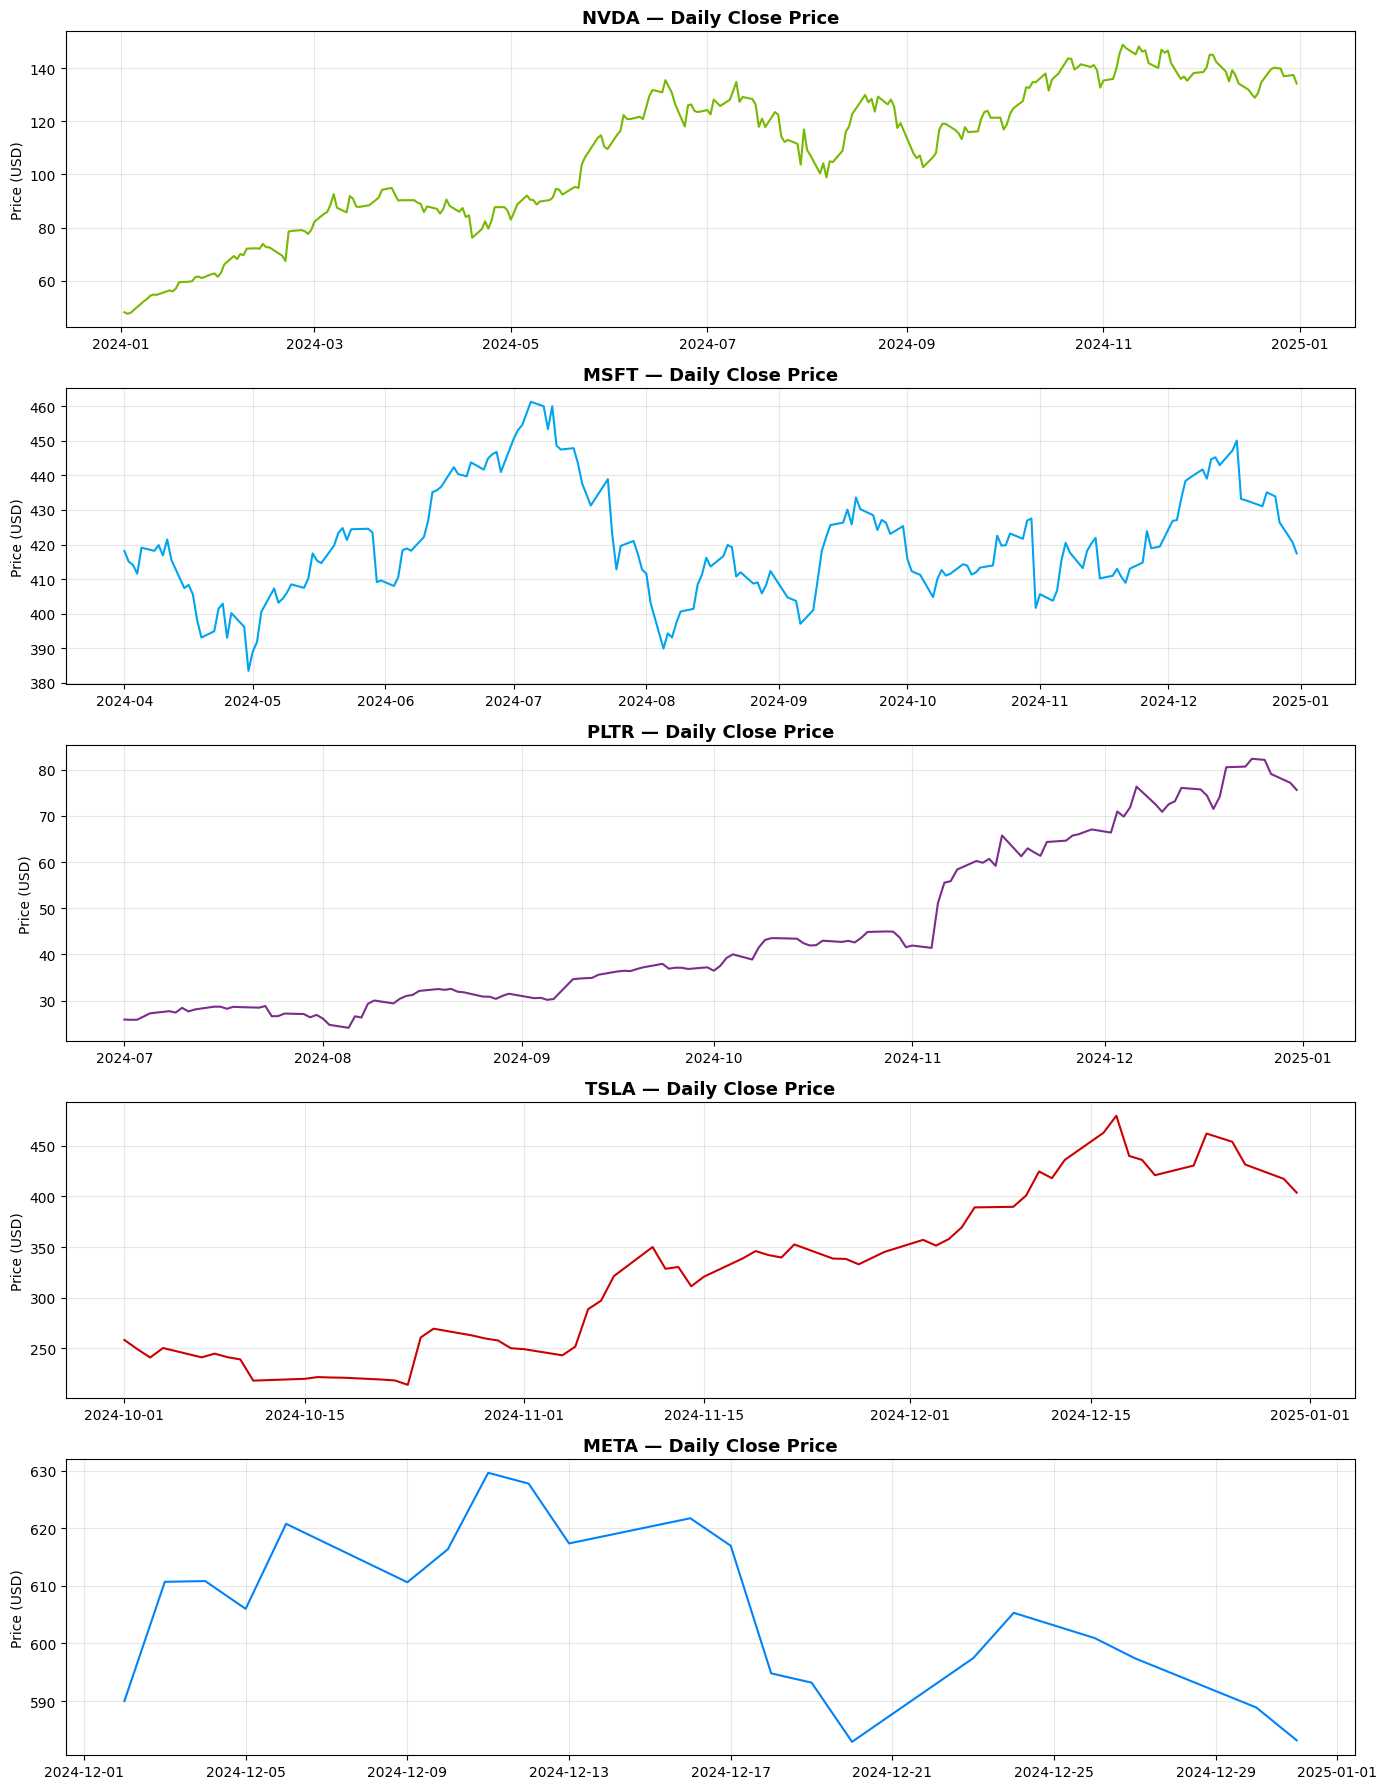

In [17]:
colors = {"NVDA": "#76b900", "MSFT": "#00a4ef", "PLTR": "#7b2d8b", "TSLA": "#cc0000", "META": "#0082fb"}

fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for ax, (ticker, df) in zip(axes, all_clean.items()):
    ax.plot(df["Date"], df["Close"], color=colors[ticker], linewidth=1.5)
    ax.set_title(f"{ticker} — Daily Close Price", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (USD)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("individual_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

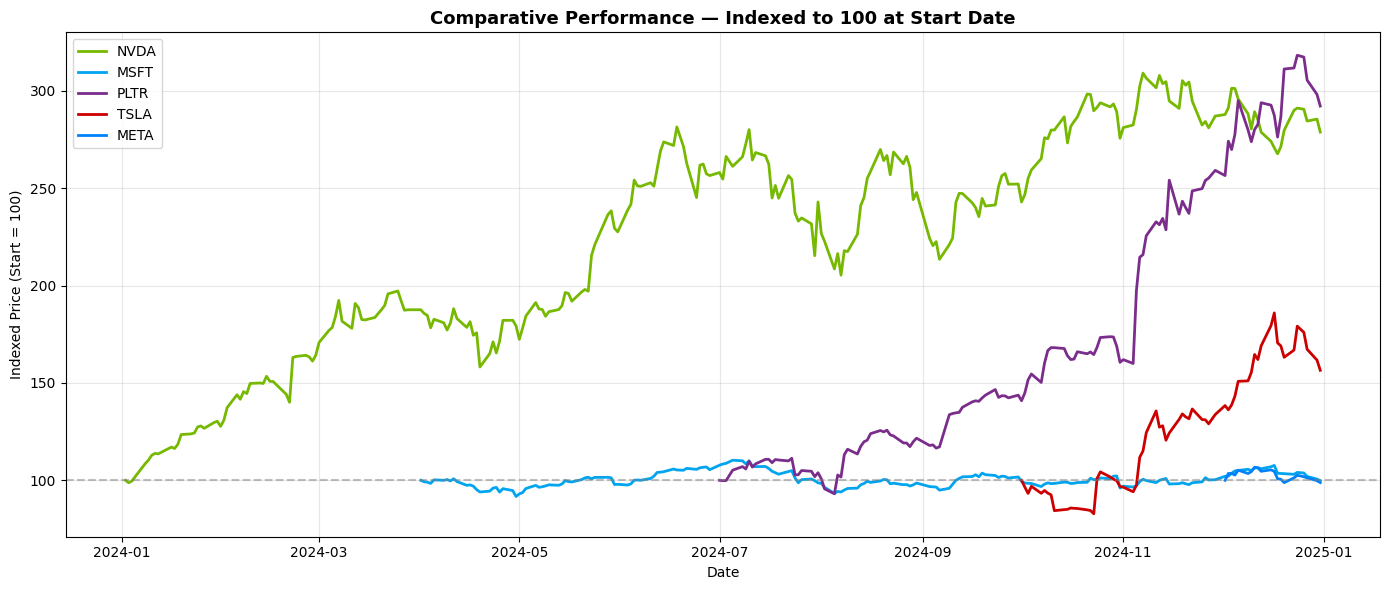

In [18]:
plt.figure(figsize=(14, 6))

for ticker, df in all_clean.items():
    normalized = df["Close"] / df["Close"].iloc[0] * 100
    plt.plot(df["Date"], normalized, label=ticker, color=colors[ticker], linewidth=2)

plt.axhline(y=100, color="gray", linestyle="--", alpha=0.5)
plt.title("Comparative Performance — Indexed to 100 at Start Date", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("normalized_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
print("KPI A — DATA COMPLETENESS")
print("="*55)
print(f"{'Ticker':<8} {'Total Rows':<14} {'Missing':<10} {'Completeness'}")
print("-"*55)

for ticker, df in all_clean.items():
    total = len(df)
    missing = df["Close"].isnull().sum()
    completeness = (1 - missing / total) * 100
    print(f"{ticker:<8} {total:<14} {missing:<10} {completeness:.2f}%")

KPI A — DATA COMPLETENESS
Ticker   Total Rows     Missing    Completeness
-------------------------------------------------------
NVDA     252            0          100.00%
MSFT     191            0          100.00%
PLTR     128            0          100.00%
TSLA     64             0          100.00%
META     21             0          100.00%


In [20]:
print("KPI B — DATA LATENCY")
print("="*65)
print(f"{'Ticker':<8} {'First Record':<15} {'Last Record':<15} {'Data Age (days)'}")
print("-"*65)

for ticker, df in all_clean.items():
    first = df["Date"].min()
    last = df["Date"].max()
    data_age = (datetime.now() - last).days
    print(f"{ticker:<8} {str(first.date()):<15} {str(last.date()):<15} {data_age} days")

KPI B — DATA LATENCY
Ticker   First Record    Last Record     Data Age (days)
-----------------------------------------------------------------
NVDA     2024-01-02      2024-12-31      471 days
MSFT     2024-04-01      2024-12-31      471 days
PLTR     2024-07-01      2024-12-31      471 days
TSLA     2024-10-01      2024-12-31      471 days
META     2024-12-02      2024-12-31      471 days


In [21]:
print("KPI C — DATA ACCURACY")
print("="*70)
print(f"{'Ticker':<8} {'Negative':<12} {'Zero':<10} {'Outliers':<12} {'Accuracy'}")
print("-"*70)

for ticker, df in all_clean.items():
    negative = (df["Close"] < 0).sum()
    zero = (df["Close"] == 0).sum()
    Q1 = df["Close"].quantile(0.25)
    Q3 = df["Close"].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df["Close"] < Q1 - 1.5*IQR) | (df["Close"] > Q3 + 1.5*IQR)).sum()
    invalid = negative + zero
    accuracy = (len(df) - invalid) / len(df) * 100
    print(f"{ticker:<8} {negative:<12} {zero:<10} {outliers:<12} {accuracy:.2f}%")

KPI C — DATA ACCURACY
Ticker   Negative     Zero       Outliers     Accuracy
----------------------------------------------------------------------
NVDA     0            0          0            100.00%
MSFT     0            0          3            100.00%
PLTR     0            0          0            100.00%
TSLA     0            0          0            100.00%
META     0            0          0            100.00%


In [22]:
print("KPI D — DATA CONSISTENCY")
print("="*65)
print(f"{'Ticker':<8} {'Data Type':<15} {'Duplicates':<14} {'Large Gaps (>3d)'}")
print("-"*65)

for ticker, df in all_clean.items():
    dtype = str(df["Close"].dtype)
    dupes = df.duplicated().sum()
    gaps = df["Date"].diff().dropna()
    large_gaps = (gaps.dt.days > 3).sum()
    print(f"{ticker:<8} {dtype:<15} {dupes:<14} {large_gaps}")

KPI D — DATA CONSISTENCY
Ticker   Data Type       Duplicates     Large Gaps (>3d)
-----------------------------------------------------------------
NVDA     float64         0              5
MSFT     float64         0              2
PLTR     float64         0              1
TSLA     float64         0              0
META     float64         0              0


Ticker  Rows  Completeness (%)  Latency (days)  Accuracy (%)  Duplicates  Large Gaps
  NVDA   252             100.0             471         100.0           0           5
  MSFT   191             100.0             471         100.0           0           2
  PLTR   128             100.0             471         100.0           0           1
  TSLA    64             100.0             471         100.0           0           0
  META    21             100.0             471         100.0           0           0


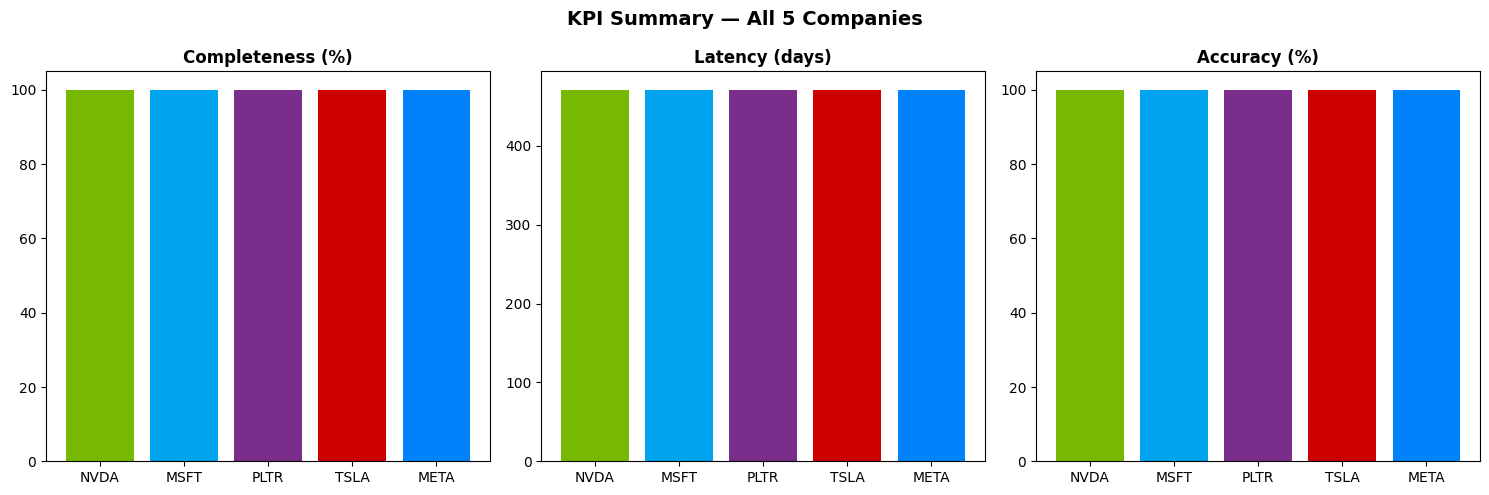

In [23]:
results = []

for ticker, df in all_clean.items():
    total = len(df)
    missing = df["Close"].isnull().sum()
    completeness = round((1 - missing / total) * 100, 2)
    data_age = (datetime.now() - df["Date"].max()).days
    negative = (df["Close"] < 0).sum()
    zero = (df["Close"] == 0).sum()
    accuracy = round((total - negative - zero) / total * 100, 2)
    dupes = df.duplicated().sum()
    gaps = df["Date"].diff().dropna()
    large_gaps = (gaps.dt.days > 3).sum()

    results.append({
        "Ticker": ticker,
        "Rows": total,
        "Completeness (%)": completeness,
        "Latency (days)": data_age,
        "Accuracy (%)": accuracy,
        "Duplicates": int(dupes),
        "Large Gaps": int(large_gaps)
    })

kpi_df = pd.DataFrame(results)
kpi_df.to_csv("kpi_summary.csv", index=False)
print(kpi_df.to_string(index=False))

# Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bar_colors = [colors[t] for t in kpi_df["Ticker"]]

axes[0].bar(kpi_df["Ticker"], kpi_df["Completeness (%)"], color=bar_colors)
axes[0].set_title("Completeness (%)", fontweight="bold")
axes[0].set_ylim(0, 105)

axes[1].bar(kpi_df["Ticker"], kpi_df["Latency (days)"], color=bar_colors)
axes[1].set_title("Latency (days)", fontweight="bold")

axes[2].bar(kpi_df["Ticker"], kpi_df["Accuracy (%)"], color=bar_colors)
axes[2].set_title("Accuracy (%)", fontweight="bold")
axes[2].set_ylim(0, 105)

plt.suptitle("KPI Summary — All 5 Companies", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("kpi_summary_chart.png", dpi=150, bbox_inches="tight")
plt.show()